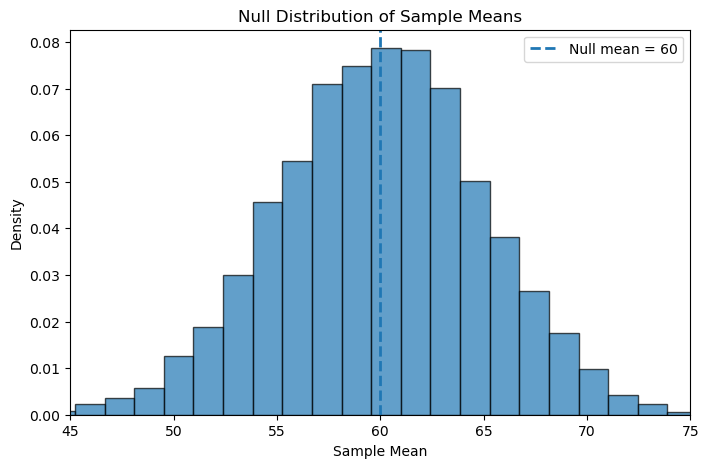

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a null distribution of sample means
np.random.seed(42)
null_means = np.random.normal(loc=60, scale=5, size=5000)

# Create histogram
plt.figure(figsize=(8, 5))
plt.hist(null_means, bins=25, density=True, edgecolor='black', alpha=0.7)

# Add line for null mean
plt.axvline(60, linestyle='--', linewidth=2, label='Null mean = 60')

plt.title("Null Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.xlim(45, 75)
plt.legend()
plt.show()

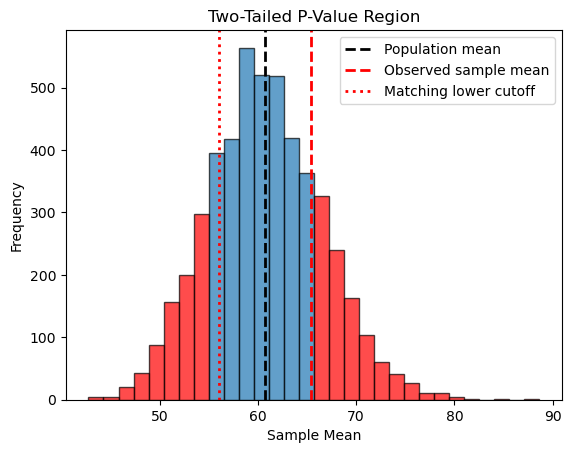

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

salmon = pd.read_csv("salmon.csv", delimiter="\t")
salmon_weight = salmon.Salmon_Weight
pop_mean = salmon_weight.mean()

secret_location_sample = [64, 66, 63, 67, 65, 68, 62, 64, 66, 65,
                          67, 63, 64, 66, 68, 65, 64, 67, 66, 65,
                          63, 64, 66, 67, 65, 68, 64, 63, 66, 67,
                          65, 64, 66, 68, 67, 65, 64, 66, 67, 63,
                          65, 66, 64, 67, 68, 65, 64, 66, 67, 65]

observed_mean = np.mean(secret_location_sample)
sample_size = len(secret_location_sample)

distance = observed_mean - pop_mean
lower_cutoff = pop_mean - distance
upper_cutoff = pop_mean + distance

null_means = []
for _ in range(5000):
    samp = np.random.choice(salmon_weight, sample_size, replace=False)
    null_means.append(np.mean(samp))

counts, bins, patches = plt.hist(null_means, bins=30, edgecolor="black", alpha=0.7)

for i in range(len(patches)):
    if bins[i+1] <= lower_cutoff or bins[i] >= upper_cutoff:
        patches[i].set_facecolor("red")

plt.axvline(pop_mean, color="black", linestyle="--", linewidth=2, label="Population mean")
plt.axvline(observed_mean, color="red", linestyle="--", linewidth=2, label="Observed sample mean")
plt.axvline(lower_cutoff, color="red", linestyle=":", linewidth=2, label="Matching lower cutoff")
plt.title("Two-Tailed P-Value Region")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

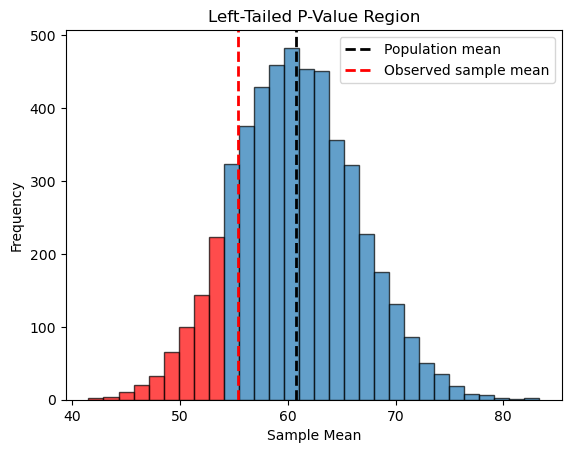

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

salmon = pd.read_csv("salmon.csv", delimiter="\t")
salmon_weight = salmon.Salmon_Weight
pop_mean = salmon_weight.mean()

secret_location_sample2 = [54, 56, 53, 57, 55, 58, 52, 54, 56, 55,
                           57, 53, 54, 56, 58, 55, 54, 57, 56, 55,
                           53, 54, 56, 57, 55, 58, 54, 53, 56, 57,
                           55, 54, 56, 58, 57, 55, 54, 56, 57, 53,
                           55, 56, 54, 57, 58, 55, 54, 56, 57, 55]

observed_mean = np.mean(secret_location_sample2)
sample_size = len(secret_location_sample2)

null_means = []
for _ in range(5000):
    samp = np.random.choice(salmon_weight, sample_size, replace=False)
    null_means.append(np.mean(samp))

counts, bins, patches = plt.hist(null_means, bins=30, edgecolor="black", alpha=0.7)

for i in range(len(patches)):
    if bins[i+1] <= observed_mean:
        patches[i].set_facecolor("red")

plt.axvline(pop_mean, color="black", linestyle="--", linewidth=2, label="Population mean")
plt.axvline(observed_mean, color="red", linestyle="--", linewidth=2, label="Observed sample mean")
plt.title("Left-Tailed P-Value Region")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()